<a href="https://colab.research.google.com/github/ArlLps/Facom_LLMs/blob/main/aula6_retrieval_augmented_generation_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6: Introdução a RAG (Retrieval-Augmented Generation)

Objetivos:

- Entender o pipeline completo de um sistema RAG
- Implementar:
  - Chunking
  - Geração de embeddings
  - Busca vetorial por similaridade
  - Geração de resposta condicionada ao contexto recuperado
- Analisar como a recuperação influencia a qualidade da resposta


Nesta aula vamos usar o seguinte roteiro prático:

1. Criar uma mini base de conhecimento (docs).
2. Fazer *chunking* (segmentação) para obter unidades recuperáveis.
3. Gerar embeddings e implementar uma busca vetorial simples.
4. Montar o *contexto* (augmentation) com os chunks mais relevantes.
5. Passar o contexto para um modelo gerador (generator) e obter uma resposta (*RAG completo*).


## 1) Setup do ambiente


In [157]:
# Se necessário, instale as seguintes dependências:
# !pip install -U sentence-transformers transformers torch scikit-learn numpy pandas matplotlib

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch


## 2) Mini Base de Conhecimento


In [158]:
# Mini base de conhecimento (exemplo didático).
# Dica: substitua por trechos do seu domínio (FAQ, políticas, docs, etc.).

docs = [
    {
        "id": "doc1",
        "text": '''
        A poesia é um gênero literário que utiliza a estética da linguagem para evocar emoções.
        O poema é tradicionalmente estruturado em linhas que recebem o nome de versos.
        Um conjunto agrupado de versos é denominado estrofe.
        '''
    },
    {
        "id": "doc2",
        "text": '''
        A métrica refere-se à medida das sílabas poéticas de um verso.
        O ritmo do poema é construído pela alternância entre sílabas tônicas e átonas.
        As rimas ocorrem quando há repetição de sons foneticamente semelhantes no final dos versos.
        '''
    },
    {
        "id": "doc3",
        "text": '''
        O soneto é um poema de forma fixa composto exatamente por quatorze versos.
        A literatura de cordel é uma expressão poética muito popular na região Nordeste do Brasil.
        O haicai é uma forma poética concisa de origem japonesa estruturada em apenas três versos.
        '''
    },
    {
        "id": "doc4",
        "text": '''
        O "eu lírico" é a voz fictícia que se expressa em um poema.
        Esta voz poética não deve ser confundida com o autor real da obra.
        O eu lírico transmite subjetividade e sentimentos pessoais ao leitor.
        '''
    },
    {
        "id": "doc5",
        "text": '''
        A poesia épica é caracterizada por narrar feitos grandiosos e heroicos.
        Um dos maiores exemplos de poema épico em língua portuguesa é a obra Os Lusíadas.
        Nesse estilo, o poeta atua mais como um narrador de fatos históricos ou mitológicos.
        '''
    },
    {
        "id": "doc6",
        "text": '''
        A metáfora é uma figura de linguagem muito comum na poesia clássica e moderna.
        Ela consiste em uma comparação implícita entre dois elementos de universos distintos.
        A personificação ocorre quando o poeta atribui características humanas a seres inanimados.
        '''
    },
    {
        "id": "doc7",
        "text": '''
        O Trovadorismo foi o primeiro movimento literário da língua portuguesa durante a Idade Média.
        Os poemas dessa época eram chamados de cantigas e nasceram para ser cantados com instrumentos.
        As cantigas dividiam-se principalmente em cantigas de amor, de amigo, de escárnio e de maldizer.
        '''
    },
    {
        "id": "doc8",
        "text": '''
        O Romantismo na poesia brasileira valorizou o sentimentalismo exagerado e o nacionalismo.
        A idealização da mulher amada é uma marca forte dos poetas da segunda geração romântica.
        Álvares de Azevedo e Castro Alves são nomes icônicos da poesia romântica no Brasil.
        '''
    },
    {
        "id": "doc9",
        "text": '''
        O Parnasianismo foi um movimento poético que defendeu o princípio da "arte pela arte".
        Os parnasianos buscavam a perfeição formal, usando vocabulário culto e métrica rigorosa.
        Olavo Bilac foi um dos poetas parnasianos mais famosos e cultuados do Brasil.
        '''
    },
    {
        "id": "doc10",
        "text": '''
        O Simbolismo na poesia destacou-se pela profunda musicalidade e pelo misticismo.
        Os poetas simbolistas utilizavam figuras como a aliteração para criar efeitos sonoros sugestivos.
        No Brasil, Cruz e Sousa e Alphonsus de Guimaraens foram os principais representantes da estética simbolista.
        '''
    },
    {
        "id": "doc11",
        "text": '''
        O Modernismo brasileiro revolucionou a poesia a partir da Semana de Arte Moderna de 1922.
        Os poetas modernistas abandonaram as regras rígidas e adotaram o verso livre.
        A linguagem coloquial e os temas do cotidiano ganharam destaque nos versos de Mário de Andrade.
        '''
    },
    {
        "id": "doc12",
        "text": '''
        A Poesia Concreta surgiu na década de 1950 com foco na materialidade da palavra.
        O movimento abandonou a estrutura linear tradicional de versos e estrofes.
        Os poemas concretos exploram o espaço visual da página e a disposição gráfica das letras.
        '''
    },
    {
        "id": "doc13",
        "text": '''
        A Poesia Marginal ganhou força no Brasil durante a década de 1970 sob o regime militar.
        As obras eram impressas em mimeógrafos e distribuídas de forma independente pelos próprios autores.
        Ana Cristina Cesar e Paulo Leminski foram figuras de destaque dessa geração contracultural.
        '''
    },
    {
        "id": "doc14",
        "text": '''
        O Slam de poesia é uma competição de poesia falada que surgiu nos centros urbanos.
        Esses eventos valorizam a performance oral, a expressão corporal e o engajamento social.
        As temáticas do slam frequentemente envolvem denúncias de racismo, machismo e desigualdade.
        '''
    },
    {
        "id": "doc15",
        "text": '''
        O ritmo interno de um poema é ditado pela alternância de sílabas tônicas e átonas.
        A assonância é a repetição de sons vocálicos idênticos para reforçar o ritmo poético.
        A aliteração foca na repetição de sons consonantais para criar uma atmosfera sonora específica.
        '''
    },
    {
        "id": "doc16",
        "text": '''
        As rimas ricas ocorrem quando as palavras que rimam pertencem a classes gramaticais diferentes.
        As rimas pobres são formadas por palavras da mesma classe gramatical, como dois verbos no infinitivo.
        Rimas emparelhadas seguem o esquema AABB, conectando os versos em pares sucessivos.
        '''
    },
    {
        "id": "doc17",
        "text": '''
        O poema em prosa não utiliza versos, mas mantém a carga poética através de imagens e lirismo.
        A prosa poética flui em parágrafos normais, contudo prioriza a sonoridade e a emoção.
        Esse formato permite ao autor explorar a beleza da linguagem sem a restrição da métrica.
        '''
    },
    {
        "id": "doc18",
        "text": '''
        A antologia poética é uma coleção publicada que reúne diversos poemas e autores.
        Antologias podem ser organizadas por tema, período histórico ou afinidade estilística.
        Elas são excelentes ferramentas de estudo para observar a evolução da poesia ao longo do tempo.
        '''
    }
]


## 3) Chunking (segmentação) - construção de contexto

Nesta aula, vamos usar sentenças como chunks (simples e didático).  
Em produção, você normalmente usa chunking por **tamanho** (tokens/caracteres) + **overlap**.


In [159]:
def split_sentences_pt(text: str) -> list[str]:
    # Segmentação simplificada (por ponto).
    return [s.strip() for s in text.split(".") if len(s.strip()) > 0]

rows = []
for doc in docs:
    sentences = split_sentences_pt(doc["text"])
    for sent in sentences:
        rows.append({
            "doc_id": doc["id"],
            "sentence": sent
        })

df = pd.DataFrame(rows)
df


,doc_id,sentence
0,doc1,A poesia é um gênero literário que utiliza a e...
1,doc1,O poema é tradicionalmente estruturado em linh...
2,doc1,Um conjunto agrupado de versos é denominado es...
3,doc2,A métrica refere-se à medida das sílabas poéti...
4,doc2,O ritmo do poema é construído pela alternância...
5,doc2,As rimas ocorrem quando há repetição de sons f...
6,doc3,O soneto é um poema de forma fixa composto exa...
7,doc3,A literatura de cordel é uma expressão poética...
8,doc3,O haicai é uma forma poética concisa de origem...
9,doc4,"O ""eu lírico"" é a voz fictícia que se expressa..."


## 4) Gerar embeddings (Retriever, R do RAG)

Usaremos um modelo encoder-only do SentenceTransformers para gerar embeddings dos chunks.


In [160]:
model_emb = SentenceTransformer("neuralmind/bert-base-portuguese-cased")

sentences = df["sentence"].tolist()
embeddings = model_emb.encode(sentences)

df["embedding"] = list(embeddings)
df.head()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,doc_id,sentence,embedding
0,doc1,A poesia é um gênero literário que utiliza a e...,"[0.07447122, 0.07009671, 0.5835832, 0.07412334..."
1,doc1,O poema é tradicionalmente estruturado em linh...,"[0.33475047, -0.05121124, 0.5564059, 0.1834409..."
2,doc1,Um conjunto agrupado de versos é denominado es...,"[0.47753918, -0.10200583, 0.5941133, 0.1396430..."
3,doc2,A métrica refere-se à medida das sílabas poéti...,"[0.06628568, 0.03339769, 0.65979576, 0.2014996..."
4,doc2,O ritmo do poema é construído pela alternância...,"[0.114671595, 0.053789377, 0.70187014, 0.02336..."


## 5) Busca vetorial por similaridade (R do RAG)

Implementação minimalista com similaridade cosseno.  
(Em produção, isso vai para um índice/banco vetorial: FAISS, Milvus, Pinecone, Weaviate, pgvector, etc.)


In [161]:
def retrieve(query: str, top_k: int = 3) -> pd.DataFrame:
    query_emb = model_emb.encode([query])
    matrix = np.vstack(df["embedding"].values)

    sims = cosine_similarity(query_emb, matrix)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = df.iloc[top_idx].copy()
    results["score"] = sims[top_idx]
    return results

query = "O que é o \"eu lírico\" em um poema?"
retrieve(query, top_k=5)


,doc_id,sentence,embedding,score
9,doc4,"O ""eu lírico"" é a voz fictícia que se expressa...","[0.106487066, 0.0737234, 0.4740553, 0.16372967...",0.870762
11,doc4,O eu lírico transmite subjetividade e sentimen...,"[0.16567567, 0.003752636, 0.3589235, -0.045716...",0.754256
6,doc3,O soneto é um poema de forma fixa composto exa...,"[0.5511203, 0.023223998, 0.3258735, 0.18171331...",0.715688
48,doc17,"O poema em prosa não utiliza versos, mas manté...","[0.20814036, 0.04307195, 0.13737442, 0.0427199...",0.713015
10,doc4,Esta voz poética não deve ser confundida com o...,"[0.19428627, -0.07170467, 0.38609692, 0.231222...",0.710430


## 6) Montando o contexto (Augmentation, A do RAG)

Agora agregamos os chunks recuperados em um bloco de texto que será injetado no prompt.


In [162]:
def build_context(query: str, top_k: int = 3) -> str:
    retrieved = retrieve(query, top_k)
    context = "\n".join(retrieved["sentence"].tolist())
    return context

context = build_context(query, top_k=5)
print(context)


O "eu lírico" é a voz fictícia que se expressa em um poema
O eu lírico transmite subjetividade e sentimentos pessoais ao leitor
O soneto é um poema de forma fixa composto exatamente por quatorze versos
O poema em prosa não utiliza versos, mas mantém a carga poética através de imagens e lirismo
Esta voz poética não deve ser confundida com o autor real da obra


## 7) Parte gerativa (Generation, G do RAG)

Aqui usamos um modelo causal pequeno para fins didáticos. Troque o distilgpt2 para o gemma 3 para melhores resultados.


In [163]:
model_name = "distilgpt2" # Modelo pequeno para teste rápido
#model_name = "google/gemma-3-270m" # De melhor qualidade, mas download de 0.5G

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_gen = AutoModelForCausalLM.from_pretrained(model_name)

# distilgpt-2 não tem pad_token necessário para a geração
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 8) Pipeline RAG simples

1. Recupera chunks (Retriever)  
2. Monta contexto (Augmentation)  
3. Gera resposta condicionada (Generator)


In [164]:
def rag_answer(query: str, top_k: int = 3, max_tokens: int = 150) -> str:
    context = build_context(query, top_k)

    prompt = f"""Responda à pergunta usando apenas o contexto abaixo.

Contexto:
{context}

Pergunta:
{query}

Resposta:
"""

    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model_gen.generate(
            **inputs,
            max_new_tokens=max_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return answer

rag_answer(query, top_k=5)


'Responda à pergunta usando apenas o contexto abaixo.\n\nContexto:\nO "eu lírico" é a voz fictícia que se expressa em um poema\nO eu lírico transmite subjetividade e sentimentos pessoais ao leitor\nO soneto é um poema de forma fixa composto exatamente por quatorze versos\nO poema em prosa não utiliza versos, mas mantém a carga poética através de imagens e lirismo\nEsta voz poética não deve ser confundida com o autor real da obra\n\nPergunta:\nO que é o "eu lírico" em um poema?\n\nResposta:\nO "eu lírico" é a voz fictícia que se expressa em um poema?\nResposta:\nO "eu lírico" é a voz fictícia que se expressa em um poema?\nResposta:\nO "eu lírico" é a voz fictícia que se expressa em um poema?\nResposta:\nO "eu lírico" é a voz fictícia que se expressa em um poema?\nResposta:\nO "eu lírico" é a voz fictícia que se expressa em um poema?\nResposta:\n'

## 9) Visualizando similaridade (conexão com Embeddings)

Vamos projetar os embeddings em 2D com PCA para observar agrupamentos.


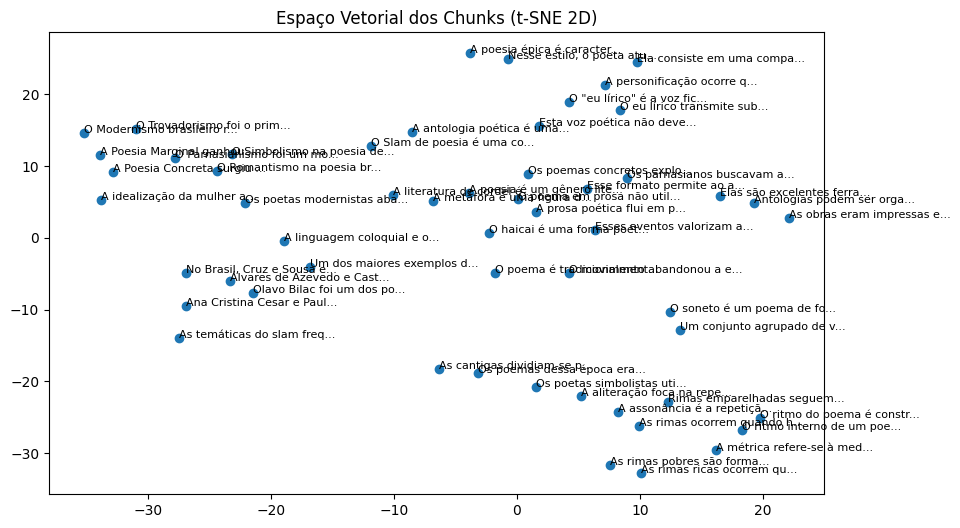

In [169]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE # Import TSNE
import matplotlib.pyplot as plt

X = np.vstack(df["embedding"].values)

# Use t-SNE instead of PCA
ts = TSNE(n_components=2, random_state=42, perplexity=5) # Added random_state for reproducibility and fixed perplexity
X2 = ts.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X2[:, 0], X2[:, 1])

for i, txt in enumerate(df["sentence"]):
    plt.annotate(txt[:25] + ("..." if len(txt) > 25 else ""), (X2[i, 0], X2[i, 1]), fontsize=8)

plt.title("Espaço Vetorial dos Chunks (t-SNE 2D)") # Update title
plt.show()

## 10) Experimentos

Tente rodar as células abaixo e discutir os resultados.

- O que acontece se `top_k = 1`?
- E se aumentarmos para `top_k = 5`?
- Faça uma pergunta fora do domínio da base (para ver como o sistema se comporta).
- Modifique os documentos e observe o impacto na resposta.
